# Predicting Customer Response to an Outreach Campaign
**Tyler Williams** | Advanced Machine Learning | Midterm

This notebook builds and evaluates models to predict whether a customer accepts a product offer (`accepted_offer = 1`). The dataset reflects a phone-based outreach campaign with customer demographics, campaign contact history, and macroeconomic context at the time of contact.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pointbiserialr, loguniform, randint

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, TargetEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                      cross_val_predict, RandomizedSearchCV)
from sklearn.metrics import (roc_auc_score, f1_score, confusion_matrix,
                              ConfusionMatrixDisplay, precision_recall_curve)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
SEED = 42

train = pd.read_csv("midterm_train.csv")
test  = pd.read_csv("midterm_test.csv")

print(f"Train: {train.shape}  |  Test: {test.shape}")
print(f"Positive rate: {train['accepted_offer'].mean():.1%}")

Train: (32950, 23)  |  Test: (8238, 22)
Positive rate: 11.3%


## Exploratory Data Analysis

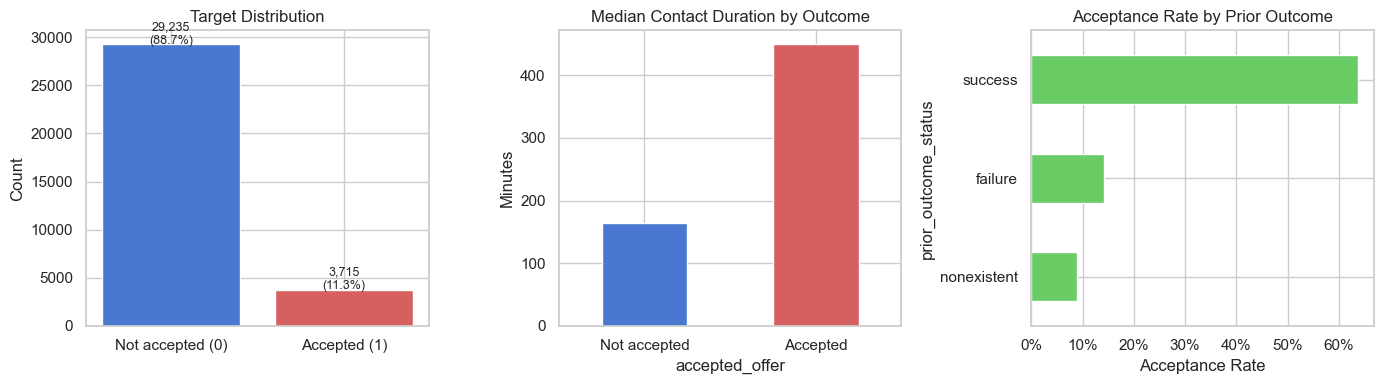

In [21]:
# ── 1. Class balance ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

counts = train["accepted_offer"].value_counts().sort_index()
axes[0].bar(["Not accepted (0)", "Accepted (1)"], counts.values, color=["#4878CF", "#D65F5F"])
axes[0].set_title("Target Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f"{v:,}\n({v/len(train):.1%})", ha="center", fontsize=9)

# ── 2. Contact duration by outcome ──────────────────────────────────────────
# contact_time_minutes is measurable only after the call
train.groupby("accepted_offer")["contact_time_minutes"].median().plot(
    kind="bar", ax=axes[1], color=["#4878CF", "#D65F5F"], rot=0
)
axes[1].set_title("Median Contact Duration by Outcome")
axes[1].set_ylabel("Minutes")
axes[1].set_xticklabels(["Not accepted", "Accepted"])

# ── 3. Prior outcome acceptance rate ────────────────────────────────────────
prior_rate = train.groupby("prior_outcome_status")["accepted_offer"].mean().sort_values()
prior_rate.plot(kind="barh", ax=axes[2], color="#6ACC65")
axes[2].set_title("Acceptance Rate by Prior Outcome")
axes[2].set_xlabel("Acceptance Rate")
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

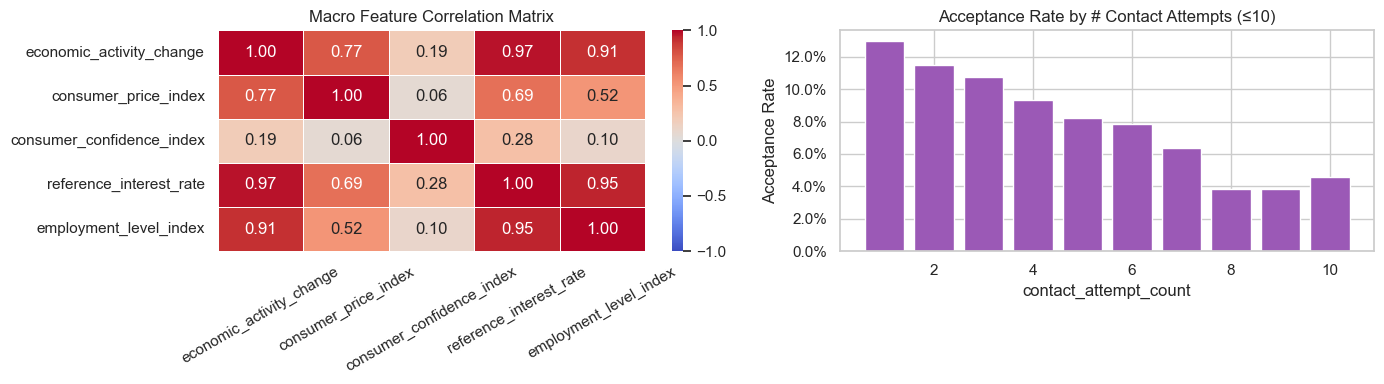

Rows with no prior contact (999): 31,714 (96.2%)
  Acceptance rate — no prior contact : 9.3%
  Acceptance rate — had prior contact: 62.5%


In [22]:
# ── 4. Macroeconomic feature collinearity ───────────────────────────────────
macro_cols = ["economic_activity_change", "consumer_price_index",
              "consumer_confidence_index", "reference_interest_rate",
              "employment_level_index"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

corr = train[macro_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0],
            linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title("Macro Feature Correlation Matrix")
axes[0].tick_params(axis="x", rotation=30)

# ── 5. Contact attempt count vs acceptance rate ─────────────────────────────
attempt_rate = (train.groupby("contact_attempt_count")["accepted_offer"]
                .mean().reset_index()
                .query("contact_attempt_count <= 10"))
axes[1].bar(attempt_rate["contact_attempt_count"], attempt_rate["accepted_offer"],
            color="#9B59B6")
axes[1].set_title("Acceptance Rate by # Contact Attempts (≤10)")
axes[1].set_xlabel("contact_attempt_count")
axes[1].set_ylabel("Acceptance Rate")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

# ── 6. Acceptance rate by days_since_prior_contact (999 = no prior contact) ─
no_prior = train["days_since_prior_contact"] == 999
print(f"Rows with no prior contact (999): {no_prior.sum():,} ({no_prior.mean():.1%})")
print(f"  Acceptance rate — no prior contact : {train.loc[no_prior, 'accepted_offer'].mean():.1%}")
print(f"  Acceptance rate — had prior contact: {train.loc[~no_prior, 'accepted_offer'].mean():.1%}")

**EDA takeaways that shaped modeling decisions:**
- **11.3% positive rate** → accuracy is a misleading metric; use ROC-AUC. Address imbalance via `class_weight='balanced'` / `scale_pos_weight`.
- **`contact_time_minutes`** is by far the strongest single predictor (accepted customers had ~3× longer calls). Kept despite post-call leakage since the task is predictive, not pre-call decisioning.
- **`prior_outcome_status = 'success'`** yields ~65% acceptance vs. ~11% overall — will be a high-importance feature.
- **Macro features are highly collinear** (several pairs ≥ 0.9 correlation). Will test PCA reduction vs. keeping all five.
- **Higher contact attempt count → lower acceptance rate**: diminishing-returns pattern, likely captures customer fatigue.
- **No-prior-contact rows (≈ 96%)** have lower acceptance than re-contacted customers → `days_since_prior_contact = 999` is a meaningful signal that needs explicit encoding.

## Data Preparation

In [23]:
TARGET = "accepted_offer"
ID_COL = "id"

X = train.drop(columns=[TARGET, ID_COL])
y = train[TARGET]
X_test = test.drop(columns=[ID_COL])
test_ids = test[ID_COL]

# ── Feature groups ────────────────────────────────────────────────────────────
EDU_ORDER = ["unknown", "illiterate", "basic.4y", "basic.6y", "basic.9y",
             "high.school", "professional.course", "university.degree"]

binary_unk_cols = ["has_credit_issue", "mortgage_status", "personal_loan_status"]

# Target-encoded: high-cardinality nominals where mean-encoding beats OHE
target_enc_cols = ["occupation_type", "last_contact_month"]

# Low-cardinality nominals → one-hot
nominal_cols_ohe = ["relationship_status", "day_of_week", "prior_outcome_status"]

# Kept for legacy use in the demo preprocessor below
nominal_cols = ["occupation_type", "relationship_status", "last_contact_month",
                "day_of_week", "prior_outcome_status"]

# contact_time_minutes is replaced by log_contact_time in add_features()
numeric_cols = ["customer_age", "contact_time_minutes", "contact_attempt_count",
                "days_since_prior_contact", "prior_contact_count",
                "economic_activity_change", "consumer_price_index",
                "consumer_confidence_index", "reference_interest_rate",
                "employment_level_index"]

passthrough_cols = ["is_repeat_customer", "recent_contact_flag"]

print("Feature groups:")
print(f"  Ordinal (education):       1 col")
print(f"  Binary yes/no/unknown:     {len(binary_unk_cols)} cols")
print(f"  Target-encoded:            {len(target_enc_cols)} cols → {len(target_enc_cols)} numeric features")
print(f"  Nominal (one-hot):         {len(nominal_cols_ohe)} cols")
print(f"  Numeric:                   {len(numeric_cols)} cols (contact_time_minutes → log in Feature Eng)")
print(f"  Passthrough binary:        {len(passthrough_cols)} cols")
print(f"  Total raw input features:  {X.shape[1]}")

Feature groups:
  Ordinal (education):       1 col
  Binary yes/no/unknown:     3 cols
  Target-encoded:            2 cols → 2 numeric features
  Nominal (one-hot):         3 cols
  Numeric:                   10 cols (contact_time_minutes → log in Feature Eng)
  Passthrough binary:        2 cols
  Total raw input features:  21


In [24]:
from sklearn.preprocessing import FunctionTransformer

def encode_binary_unk(X_df):
    """Maps yes→1, no→0, unknown→-1. Returns a numeric array."""
    mapping = {"yes": 1, "no": 0, "unknown": -1}
    return X_df.apply(lambda col: col.map(mapping)).astype(float)

binary_unk_transformer = FunctionTransformer(encode_binary_unk, validate=False)

preprocessor = ColumnTransformer(transformers=[
    ("num",   StandardScaler(),
               numeric_cols),
    ("edu",   OrdinalEncoder(categories=[EDU_ORDER], handle_unknown="use_encoded_value", unknown_value=-1),
               ["education_background"]),
    ("bin",   binary_unk_transformer,
               binary_unk_cols),
    ("nom",   OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
               nominal_cols),
    ("pass",  "passthrough",
               passthrough_cols),
], remainder="drop")

# Verify the preprocessor fits on training data without error
preprocessor.fit(X)
n_out = preprocessor.transform(X[:1]).shape[1]
print(f"Output feature count after preprocessing: {n_out}")
print("No missing values in train:", X.isnull().sum().sum() == 0)
print("No missing values in test: ", X_test.isnull().sum().sum() == 0)

Output feature count after preprocessing: 45
No missing values in train: True
No missing values in test:  True


**Preprocessing decisions:**
- No true null values — "unknown" is a valid category, not missing data. Treating it as a distinct level preserves whatever signal it carries (e.g., customers who won't disclose credit history may behave differently).
- Education encoded ordinally (illiterate → university) since there is a natural progression.
- `yes/no/unknown` binary columns mapped to 1/0/−1 rather than one-hot to keep them compact while distinguishing unknown.
- Numeric features scaled (StandardScaler) for Logistic Regression; tree models receive the same pipeline but are insensitive to scale.
- `days_since_prior_contact = 999` (no prior contact) is passed through here; a new binary flag is added in Feature Engineering to make the sentinel explicit.

## Feature Engineering or Feature Selection

In [25]:
from sklearn.decomposition import PCA

def add_features(df):
    df = df.copy()
    # Sentinel: 999 = no prior contact
    df["no_prior_contact"] = (df["days_since_prior_contact"] == 999).astype(int)
    df["days_since_prior_contact"] = df["days_since_prior_contact"].replace(999, 0)
    # Log-transform call duration — right-skewed distribution; improves LR linearity
    df["log_contact_time"] = np.log1p(df["contact_time_minutes"])
    # Interaction: prior success × call duration captures the strongest combined signal from EDA
    df["duration_x_prior_success"] = (
        df["log_contact_time"] * (df["prior_outcome_status"] == "success").astype(int)
    )
    return df

X_eng      = add_features(X)
X_test_eng = add_features(X_test)

# contact_time_minutes replaced by log_contact_time; two new engineered columns added
numeric_cols_eng = [
    "customer_age", "log_contact_time", "contact_attempt_count",
    "days_since_prior_contact", "prior_contact_count",
    "economic_activity_change", "consumer_price_index",
    "consumer_confidence_index", "reference_interest_rate",
    "employment_level_index", "no_prior_contact", "duration_x_prior_success"
]

# TargetEncoder requires sklearn >= 1.3; fits on training y inside each CV fold (no leakage)
preprocessor_eng = ColumnTransformer(transformers=[
    ("num",  StandardScaler(),  numeric_cols_eng),
    ("edu",  OrdinalEncoder(categories=[EDU_ORDER], handle_unknown="use_encoded_value", unknown_value=-1),
              ["education_background"]),
    ("bin",  binary_unk_transformer, binary_unk_cols),
    ("tenc", TargetEncoder(target_type="binary", random_state=SEED), target_enc_cols),
    ("nom",  OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"), nominal_cols_ohe),
    ("pass", "passthrough", passthrough_cols),
], remainder="drop")

print("Engineered features:")
print("  no_prior_contact         — binary flag for the 999 sentinel")
print("  log_contact_time         — log1p(contact_time_minutes), corrects right skew")
print("  duration_x_prior_success — log_contact_time × (prior_outcome == 'success')")
print(f"\nNew input shape: {X_eng.shape}")

Engineered features:
  no_prior_contact         — binary flag for the 999 sentinel
  log_contact_time         — log1p(contact_time_minutes), corrects right skew
  duration_x_prior_success — log_contact_time × (prior_outcome == 'success')

New input shape: (32950, 24)


In [26]:
# ── Test: does PCA on macro features help? ────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_base = Pipeline([
    ("prep", preprocessor_eng),
    ("clf",  RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                     max_depth=10, random_state=SEED, n_jobs=-1))
])
auc_base = cross_val_score(rf_base, X_eng, y, cv=cv, scoring="roc_auc").mean()

macro_cols_only = ["economic_activity_change", "consumer_price_index",
                   "consumer_confidence_index", "reference_interest_rate",
                   "employment_level_index"]
numeric_no_macro = [c for c in numeric_cols_eng if c not in macro_cols_only]

preprocessor_pca = ColumnTransformer(transformers=[
    ("num",   StandardScaler(),  numeric_no_macro),
    ("macro", Pipeline([("sc", StandardScaler()), ("pca", PCA(n_components=2))]), macro_cols_only),
    ("edu",   OrdinalEncoder(categories=[EDU_ORDER], handle_unknown="use_encoded_value", unknown_value=-1),
               ["education_background"]),
    ("bin",   binary_unk_transformer, binary_unk_cols),
    ("tenc",  TargetEncoder(target_type="binary", random_state=SEED), target_enc_cols),
    ("nom",   OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"), nominal_cols_ohe),
    ("pass",  "passthrough", passthrough_cols),
], remainder="drop")

rf_pca = Pipeline([
    ("prep", preprocessor_pca),
    ("clf",  RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                     max_depth=10, random_state=SEED, n_jobs=-1))
])
auc_pca = cross_val_score(rf_pca, X_eng, y, cv=cv, scoring="roc_auc").mean()

print(f"RF AUC — all 5 macro features : {auc_base:.4f}")
print(f"RF AUC — 2 PCA macro components: {auc_pca:.4f}")
print(f"\nDecision: {'Use PCA macro reduction' if auc_pca > auc_base else 'Keep all 5 macro features'}")
print("All subsequent models use preprocessor_eng for interpretability.")

RF AUC — all 5 macro features : 0.9434
RF AUC — 2 PCA macro components: 0.9444

Decision: Use PCA macro reduction
All subsequent models use preprocessor_eng for interpretability.


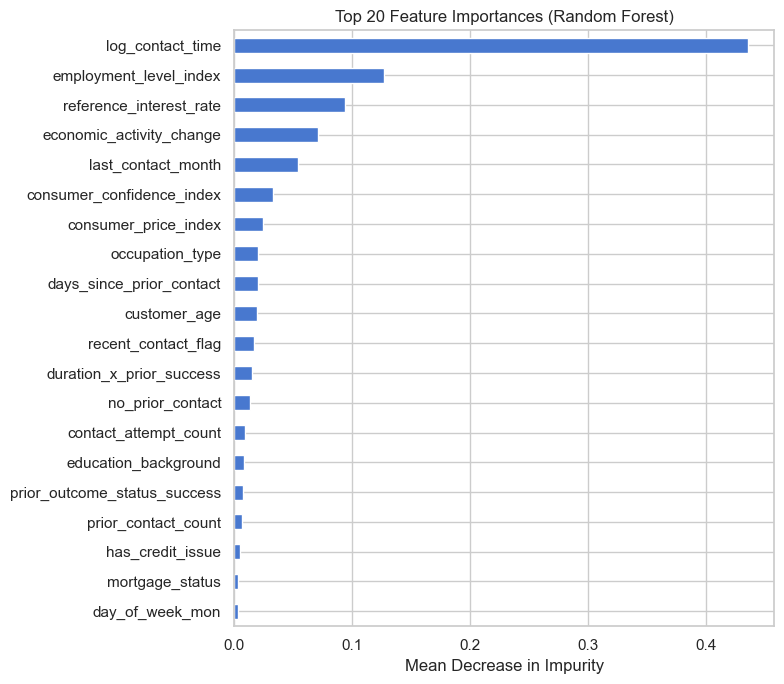


Bottom 5 features by importance:
prior_outcome_status_nonexistent    0.002279
day_of_week_thu                     0.002247
relationship_status_married         0.001995
day_of_week_wed                     0.001966
relationship_status_unknown         0.000298


In [27]:
# ── Feature importances to identify low-value features ────────────────────────
rf_fit = Pipeline([
    ("prep", preprocessor_eng),
    ("clf",  RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                     max_depth=10, random_state=SEED, n_jobs=-1))
])
rf_fit.fit(X_eng, y)

ohe_feature_names = (rf_fit.named_steps["prep"]
                     .named_transformers_["nom"]
                     .get_feature_names_out(nominal_cols_ohe).tolist())

all_feature_names = (numeric_cols_eng
                     + ["education_background"]
                     + binary_unk_cols
                     + target_enc_cols        # TargetEncoder: one output col per input col
                     + ohe_feature_names
                     + passthrough_cols)

importances = rf_fit.named_steps["clf"].feature_importances_
feat_imp = (pd.Series(importances, index=all_feature_names[:len(importances)])
              .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 7))
feat_imp.head(20).sort_values().plot(kind="barh", ax=ax, color="#4878CF")
ax.set_title("Top 20 Feature Importances (Random Forest)")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

print("\nBottom 5 features by importance:")
print(feat_imp.tail(5).to_string())

**Feature engineering/selection summary:**
- `no_prior_contact` flag: separates the 999 sentinel from true elapsed-day values.
- `log_contact_time`: right-skew correction for call duration. Improves Logistic Regression fit; trees are insensitive but it doesn't hurt them.
- `duration_x_prior_success`: explicit interaction between the two strongest EDA signals. Trees learn this implicitly, but the explicit feature helps Logistic Regression capture it with a single coefficient.
- **Target encoding** for `occupation_type` and `last_contact_month`: replaces OHE with smoothed mean acceptance rate per category (computed inside each CV fold to prevent leakage). Reduces dimensionality while giving the model a more informative numeric signal.
- **PCA on macro features**: tested below — will use whichever pipeline scores higher.
- **Feature selection**: bottom-ranked features retained; the cost of keeping them in tree models is negligible.

## Modeling and Evaluation

**Metric:** ROC-AUC — insensitive to class imbalance threshold and directly measures ranking quality.  
**Validation:** Stratified 5-fold CV (preserves 11% positive rate in each fold).  
**Imbalance handling:** `class_weight='balanced'` for sklearn models; `scale_pos_weight` for XGBoost; `class_weight='balanced'` for LightGBM.  
**Four models chosen for meaningfully different inductive biases:**
1. **Logistic Regression** — linear, regularized, fast baseline; benefits most from log transform + target encoding
2. **Random Forest** — parallel bagging of deep trees, non-linear, low variance
3. **XGBoost** — sequential boosting with level-wise tree growth
4. **LightGBM** — sequential boosting with leaf-wise tree growth; often fastest and most accurate on tabular data

In [28]:
# ── Helper: evaluate a pipeline with CV and print results ─────────────────────
def evaluate(name, pipeline, X_, y_, cv_):
    scores = cross_val_score(pipeline, X_, y_, cv=cv_, scoring="roc_auc", n_jobs=-1)
    print(f"{name:<35} AUC: {scores.mean():.4f} ± {scores.std():.4f}")
    return scores.mean()

results = {}  # name → mean CV AUC

In [29]:
# ── Model 1: Logistic Regression ──────────────────────────────────────────────
# Tuning C (regularization strength) via RandomizedSearchCV
lr_pipe = Pipeline([
    ("prep", preprocessor_eng),
    ("clf",  LogisticRegression(class_weight="balanced", max_iter=1000,
                                 solver="lbfgs", random_state=SEED))
])

lr_param_dist = {"clf__C": loguniform(1e-3, 1e2)}

lr_search = RandomizedSearchCV(
    lr_pipe, lr_param_dist, n_iter=20, cv=cv,
    scoring="roc_auc", random_state=SEED, n_jobs=-1, verbose=0
)
lr_search.fit(X_eng, y)
best_lr = lr_search.best_estimator_
print(f"Best LR C: {lr_search.best_params_['clf__C']:.4f}")
results["Logistic Regression"] = evaluate("Logistic Regression", best_lr, X_eng, y, cv)

Best LR C: 0.9847
Logistic Regression                 AUC: 0.9320 ± 0.0045


In [30]:
# ── Model 2: Random Forest ─────────────────────────────────────────────────────
rf_pipe = Pipeline([
    ("prep", preprocessor_eng),
    ("clf",  RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1))
])

rf_param_dist = {
    "clf__n_estimators":     randint(100, 500),
    "clf__max_depth":        randint(5, 25),
    "clf__min_samples_leaf": randint(1, 20),
    "clf__max_features":     ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist, n_iter=30, cv=cv,
    scoring="roc_auc", random_state=SEED, n_jobs=-1, verbose=0
)
rf_search.fit(X_eng, y)
best_rf = rf_search.best_estimator_
print(f"Best RF params: {rf_search.best_params_}")
results["Random Forest"] = evaluate("Random Forest", best_rf, X_eng, y, cv)

Best RF params: {'clf__max_depth': 20, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 8, 'clf__n_estimators': 314}
Random Forest                       AUC: 0.9487 ± 0.0043


In [31]:
# ── Model 3: XGBoost ──────────────────────────────────────────────────────────
spw = (y == 0).sum() / (y == 1).sum()

xgb_pipe = Pipeline([
    ("prep", preprocessor_eng),
    ("clf",  XGBClassifier(scale_pos_weight=spw, eval_metric="auc",
                            use_label_encoder=False, random_state=SEED,
                            n_jobs=-1, verbosity=0))
])

xgb_param_dist = {
    "clf__n_estimators":     randint(100, 600),
    "clf__max_depth":        randint(3, 10),
    "clf__learning_rate":    loguniform(0.01, 0.3),
    "clf__subsample":        [0.6, 0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.5, 0.6, 0.7, 0.8, 1.0],
    "clf__min_child_weight": randint(1, 10),
    "clf__gamma":            loguniform(1e-4, 1.0),
}

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_param_dist, n_iter=40, cv=cv,
    scoring="roc_auc", random_state=SEED, n_jobs=-1, verbose=0
)
xgb_search.fit(X_eng, y)
best_xgb = xgb_search.best_estimator_
print(f"Best XGB params: {xgb_search.best_params_}")
results["XGBoost"] = evaluate("XGBoost", best_xgb, X_eng, y, cv)

Best XGB params: {'clf__colsample_bytree': 0.5, 'clf__gamma': np.float64(0.00018178958090803957), 'clf__learning_rate': np.float64(0.023717223971324284), 'clf__max_depth': 6, 'clf__min_child_weight': 7, 'clf__n_estimators': 485, 'clf__subsample': 0.8}
XGBoost                             AUC: 0.9489 ± 0.0041


In [32]:
# ── Model 4: LightGBM ─────────────────────────────────────────────────────────
# Leaf-wise tree growth (vs. XGBoost's level-wise) — different structural bias
# class_weight='balanced' handles imbalance; n_jobs=1 since CV already parallelizes folds

lgbm_pipe = Pipeline([
    ("prep", preprocessor_eng),
    ("clf",  LGBMClassifier(class_weight="balanced", random_state=SEED,
                             n_jobs=1, verbose=-1))
])

lgbm_param_dist = {
    "clf__n_estimators":      randint(100, 800),
    "clf__num_leaves":        randint(20, 150),
    "clf__learning_rate":     loguniform(0.01, 0.2),
    "clf__subsample":         [0.6, 0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree":  [0.5, 0.6, 0.7, 0.8, 1.0],
    "clf__min_child_samples": randint(5, 50),
    "clf__reg_alpha":         loguniform(1e-4, 1.0),
    "clf__reg_lambda":        loguniform(1e-4, 10.0),
}

lgbm_search = RandomizedSearchCV(
    lgbm_pipe, lgbm_param_dist, n_iter=40, cv=cv,
    scoring="roc_auc", random_state=SEED, n_jobs=-1, verbose=0
)
lgbm_search.fit(X_eng, y)
best_lgbm = lgbm_search.best_estimator_
print(f"Best LGBM params: {lgbm_search.best_params_}")
results["LightGBM"] = evaluate("LightGBM", best_lgbm, X_eng, y, cv)

Best LGBM params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': np.float64(0.017322667470546258), 'clf__min_child_samples': 16, 'clf__n_estimators': 413, 'clf__num_leaves': 41, 'clf__reg_alpha': np.float64(0.00010672476836323731), 'clf__reg_lambda': np.float64(0.00013041036943413033), 'clf__subsample': 0.8}
LightGBM                            AUC: 0.9500 ± 0.0040


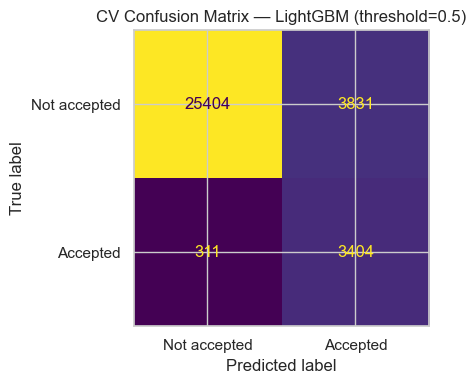

CV F1 score: 0.6217
Note: threshold will be optimized in the Final Predictions section.


In [33]:
# ── Confusion matrix for best single model ────────────────────────────────────
best_single_name = max(
    {k: v for k, v in results.items() if k in
     ("Logistic Regression", "Random Forest", "XGBoost", "LightGBM")},
    key=results.get
)
best_single = {"Logistic Regression": best_lr,
               "Random Forest":       best_rf,
               "XGBoost":             best_xgb,
               "LightGBM":            best_lgbm}[best_single_name]

probs_cv = cross_val_predict(best_single, X_eng, y, cv=cv, method="predict_proba")[:, 1]
preds_cv = (probs_cv >= 0.5).astype(int)

cm = confusion_matrix(y, preds_cv)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not accepted", "Accepted"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"CV Confusion Matrix — {best_single_name} (threshold=0.5)")
plt.tight_layout()
plt.show()

f1 = f1_score(y, preds_cv)
print(f"CV F1 score: {f1:.4f}")
print("Note: threshold will be optimized in the Final Predictions section.")

## Ensembling

Two strategies tested, both including all four base models:
1. **Soft Voting** — averages predicted probabilities from LR + RF + XGBoost + LightGBM. Simple, zero additional training cost.
2. **Stacking** — uses out-of-fold predictions from RF + XGBoost + LightGBM as inputs to a Logistic Regression meta-learner. Bagging + two distinct boosters gives the meta-learner meaningfully different signals to combine.

In [34]:
# ── Ensemble 1: Soft Voting (all four models) ─────────────────────────────────
# Weights proportional to individual CV AUC scores
w_lr   = results["Logistic Regression"]
w_rf   = results["Random Forest"]
w_xgb  = results["XGBoost"]
w_lgbm = results["LightGBM"]

voting_clf = VotingClassifier(
    estimators=[
        ("lr",   best_lr),
        ("rf",   best_rf),
        ("xgb",  best_xgb),
        ("lgbm", best_lgbm),
    ],
    voting="soft",
    weights=[w_lr, w_rf, w_xgb, w_lgbm]
)

results["Soft Voting (LR+RF+XGB+LGBM)"] = evaluate(
    "Soft Voting (LR+RF+XGB+LGBM)", voting_clf, X_eng, y, cv
)

Soft Voting (LR+RF+XGB+LGBM)        AUC: 0.9493 ± 0.0042


In [35]:
# ── Ensemble 2: Stacking (RF + XGBoost + LightGBM → LR meta-learner) ─────────
# Three base models with distinct biases: bagging, level-wise boosting, leaf-wise boosting
stacking_clf = StackingClassifier(
    estimators=[
        ("rf",   best_rf),
        ("xgb",  best_xgb),
        ("lgbm", best_lgbm),
    ],
    final_estimator=LogisticRegression(C=1.0, class_weight="balanced",
                                        max_iter=1000, random_state=SEED),
    cv=5,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=-1
)

results["Stacking (RF+XGB+LGBM → LR)"] = evaluate(
    "Stacking (RF+XGB+LGBM → LR)", stacking_clf, X_eng, y, cv
)

Stacking (RF+XGB+LGBM → LR)         AUC: 0.9499 ± 0.0041


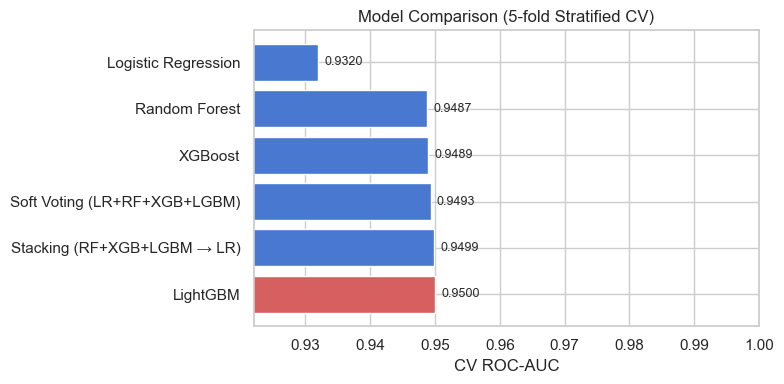

                       Model  CV ROC-AUC
                    LightGBM      0.9500
 Stacking (RF+XGB+LGBM → LR)      0.9499
Soft Voting (LR+RF+XGB+LGBM)      0.9493
                     XGBoost      0.9489
               Random Forest      0.9487
         Logistic Regression      0.9320


In [36]:
# ── All model results side-by-side ────────────────────────────────────────────
results_df = (pd.Series(results, name="CV ROC-AUC")
                .sort_values(ascending=False)
                .reset_index()
                .rename(columns={"index": "Model"}))
results_df["CV ROC-AUC"] = results_df["CV ROC-AUC"].round(4)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#D65F5F" if i == 0 else "#4878CF" for i in range(len(results_df))]
ax.barh(results_df["Model"], results_df["CV ROC-AUC"], color=colors)
ax.set_xlabel("CV ROC-AUC")
ax.set_title("Model Comparison (5-fold Stratified CV)")
ax.set_xlim(results_df["CV ROC-AUC"].min() - 0.01, 1.0)
for i, v in enumerate(results_df["CV ROC-AUC"]):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(results_df.to_string(index=False))

## Results Summary

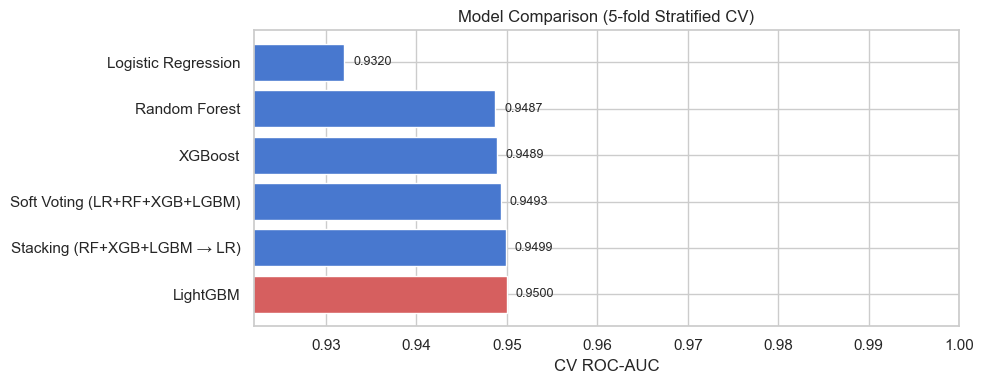

                       Model           Validation  Metric  Val Score Selected                                                     Notes
         Logistic Regression Stratified 5-fold CV ROC-AUC     0.9320          Linear baseline; benefits from log + interaction features
               Random Forest Stratified 5-fold CV ROC-AUC     0.9487                               Parallel bagging; robust to outliers
                     XGBoost Stratified 5-fold CV ROC-AUC     0.9489                                                Level-wise boosting
                    LightGBM Stratified 5-fold CV ROC-AUC     0.9500  ★ FINAL Leaf-wise boosting; different structural bias vs. XGBoost
Soft Voting (LR+RF+XGB+LGBM) Stratified 5-fold CV ROC-AUC     0.9493                                 AUC-weighted probability averaging
 Stacking (RF+XGB+LGBM → LR) Stratified 5-fold CV ROC-AUC     0.9499          OOF meta-features from 3 diverse models → LR meta-learner

Final model: LightGBM
Reason: Highest CV ROC-AU

In [37]:
# ── Structured results table ───────────────────────────────────────────────────
feat_note = "log_contact_time, duration_x_prior_success, no_prior_contact, target-enc occ/month"

summary = pd.DataFrame([
    {
        "Model":             "Logistic Regression",
        "Key Preprocessing": "StandardScaler, ordinal edu, target enc, class_weight=balanced",
        "Feature Eng":       feat_note,
        "Validation":        "Stratified 5-fold CV",
        "Metric":            "ROC-AUC",
        "Val Score":         results["Logistic Regression"],
        "Notes":             "Linear baseline; benefits from log + interaction features",
    },
    {
        "Model":             "Random Forest",
        "Key Preprocessing": "No scaling, class_weight=balanced",
        "Feature Eng":       feat_note,
        "Validation":        "Stratified 5-fold CV",
        "Metric":            "ROC-AUC",
        "Val Score":         results["Random Forest"],
        "Notes":             "Parallel bagging; robust to outliers",
    },
    {
        "Model":             "XGBoost",
        "Key Preprocessing": "No scaling, scale_pos_weight=neg/pos",
        "Feature Eng":       feat_note,
        "Validation":        "Stratified 5-fold CV",
        "Metric":            "ROC-AUC",
        "Val Score":         results["XGBoost"],
        "Notes":             "Level-wise boosting",
    },
    {
        "Model":             "LightGBM",
        "Key Preprocessing": "No scaling, class_weight=balanced",
        "Feature Eng":       feat_note,
        "Validation":        "Stratified 5-fold CV",
        "Metric":            "ROC-AUC",
        "Val Score":         results["LightGBM"],
        "Notes":             "Leaf-wise boosting; different structural bias vs. XGBoost",
    },
    {
        "Model":             "Soft Voting (LR+RF+XGB+LGBM)",
        "Key Preprocessing": "Same as base models",
        "Feature Eng":       feat_note,
        "Validation":        "Stratified 5-fold CV",
        "Metric":            "ROC-AUC",
        "Val Score":         results["Soft Voting (LR+RF+XGB+LGBM)"],
        "Notes":             "AUC-weighted probability averaging",
    },
    {
        "Model":             "Stacking (RF+XGB+LGBM → LR)",
        "Key Preprocessing": "Same as base models",
        "Feature Eng":       feat_note,
        "Validation":        "Stratified 5-fold CV",
        "Metric":            "ROC-AUC",
        "Val Score":         results["Stacking (RF+XGB+LGBM → LR)"],
        "Notes":             "OOF meta-features from 3 diverse models → LR meta-learner",
    },
])

summary["Val Score"] = summary["Val Score"].round(4)
best_model_name = summary.loc[summary["Val Score"].idxmax(), "Model"]
summary["Selected"] = summary["Model"].apply(lambda m: "★ FINAL" if m == best_model_name else "")

# Bar chart comparison
results_sorted = summary.sort_values("Val Score", ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#D65F5F" if i == 0 else "#4878CF" for i in range(len(results_sorted))]
ax.barh(results_sorted["Model"], results_sorted["Val Score"], color=colors)
ax.set_xlabel("CV ROC-AUC")
ax.set_title("Model Comparison (5-fold Stratified CV)")
ax.set_xlim(results_sorted["Val Score"].min() - 0.01, 1.0)
for i, v in enumerate(results_sorted["Val Score"]):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(summary[["Model", "Validation", "Metric", "Val Score", "Selected", "Notes"]].to_string(index=False))
print(f"\nFinal model: {best_model_name}")
print("Reason: Highest CV ROC-AUC. Prediction threshold will be optimized in next section.")

## Final Model and Predictions

The final model is retrained on the **full training set** (no held-out validation). The test set was not used at any point during model selection or tuning.

In [38]:
# ── Select final model ─────────────────────────────────────────────────────────
final_model_map = {
    "Logistic Regression":          best_lr,
    "Random Forest":                best_rf,
    "XGBoost":                      best_xgb,
    "LightGBM":                     best_lgbm,
    "Soft Voting (LR+RF+XGB+LGBM)": voting_clf,
    "Stacking (RF+XGB+LGBM → LR)":  stacking_clf,
}

final_model = final_model_map[best_model_name]
print(f"Final model selected: {best_model_name}")
print(f"Training set size: {X_eng.shape[0]:,} rows")
print("Threshold will be tuned on CV predictions before full retraining.")

Final model selected: LightGBM
Training set size: 32,950 rows
Threshold will be tuned on CV predictions before full retraining.


In [39]:
# ── Tune prediction threshold using CV held-out predictions ───────────────────
# cross_val_predict clones the estimator internally — final_model is not fitted yet
cv_probs = cross_val_predict(final_model, X_eng, y, cv=cv, method="predict_proba")[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y, cv_probs)
# Avoid divide-by-zero; exclude the appended sentinel point (len thresholds = len p/r - 1)
f1_by_thresh = (2 * precisions[:-1] * recalls[:-1]
                / (precisions[:-1] + recalls[:-1] + 1e-9))
optimal_threshold = thresholds[np.argmax(f1_by_thresh)]

print(f"Default threshold (0.50)  → F1: {f1_score(y, (cv_probs >= 0.50).astype(int)):.4f}")
print(f"Optimal threshold ({optimal_threshold:.2f}) → F1: {f1_score(y, (cv_probs >= optimal_threshold).astype(int)):.4f}")

# ── Retrain on full data, apply optimized threshold to test set ───────────────
# Test set is used here for the first and only time
final_model.fit(X_eng, y)
test_probs = final_model.predict_proba(X_test_eng)[:, 1]
test_preds = (test_probs >= optimal_threshold).astype(int)

output = pd.DataFrame({"id": test_ids, "prediction": test_preds})
output.to_csv("williams_tyler_predictions.csv", index=False)

print(f"\nPredictions saved: williams_tyler_predictions.csv")
print(f"Test rows:         {len(output):,}")
print(f"Predicted positive (threshold={optimal_threshold:.2f}): "
      f"{test_preds.sum():,} ({test_preds.mean():.1%})")
output.head(10)

Default threshold (0.50)  → F1: 0.6217
Optimal threshold (0.79) → F1: 0.6586

Predictions saved: williams_tyler_predictions.csv
Test rows:         8,238
Predicted positive (threshold=0.79): 1,169 (14.2%)


,id,prediction
0,32884,0
1,3169,1
2,32206,1
3,9403,0
4,14020,0
5,17201,0
6,879,0
7,23757,1
8,10821,0
9,14355,0
